<a href="https://colab.research.google.com/github/K121-hash/-House-Price-Prediction-Using-Linear-Regression/blob/main/House_pricing_using_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Title**

# **Predicting House Prices with Linear Regression**

# **2. Objective**

The objective of this project is to build and evaluate a Linear Regression model capable of predicting house prices using property characteristics such as location, area, number of rooms, and age.

The project covers data exploration, preprocessing, feature engineering, model training, evaluation, and interpretation of results.

# **3. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# **4. Load the Dataset**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Oasis TrainData.csv")

In [ ]:
#view first few rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# visualise the column list
print(*df.columns, sep="\n")

Id
MSSubClass
MSZoning
LotFrontage
LotArea
Street
Alley
LotShape
LandContour
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
OverallQual
OverallCond
YearBuilt
YearRemodAdd
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
Heating
HeatingQC
CentralAir
Electrical
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
KitchenQual
TotRmsAbvGrd
Functional
Fireplaces
FireplaceQu
GarageType
GarageYrBlt
GarageFinish
GarageCars
GarageArea
GarageQual
GarageCond
PavedDrive
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
PoolQC
Fence
MiscFeature
MiscVal
MoSold
YrSold
SaleType
SaleCondition
SalePrice


# **5. Dataset Overview**

In [ ]:
#check shape
df.shape

(1460, 80)

In [ ]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [ ]:
# check datatypes
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


# **6. Exploratory Data Analysis (EDA)**

In [ ]:
# check missing values
df.isnull().sum().sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
#statistical summary
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.176370,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.433457,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
# check duplicates
df.duplicated().sum()

np.int64(0)

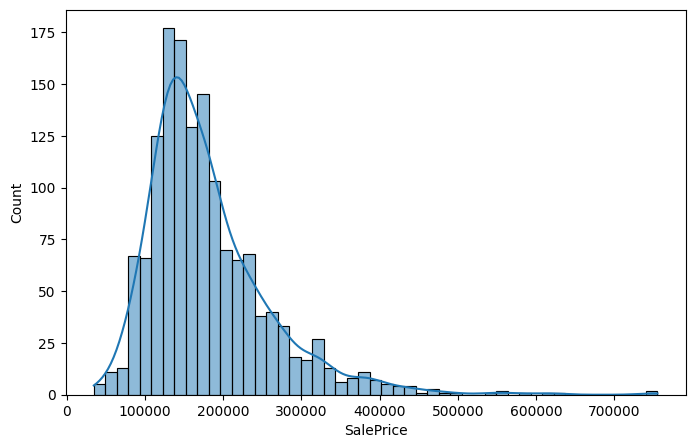

In [ ]:
#Distribution of house prices
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.show()

**Missing Values: Observation**

The dataset contains missing values in several columns. The columns with the highest number of missing values are PoolQC, MiscFeature, Alley, Fence, and MasVnrType. Some features, including SalePrice, SaleType, and SaleCondition, do not contain any missing values. The missing values will be handled during the data-cleaning stage using appropriate techniques for numerical and categorical variables.

**Descriptive Statistics:Observation**


The dataset contains 1,460 observations and 80 features, of which 38 are numerical. The average lot area is approximately 10,517 square feet, while the average house quality rating (OverallQual) is around 6 on a scale of 1 to 10. The houses in the dataset were built between 1872 and 2010, with an average construction year of approximately 1971. These statistics provide an initial understanding of the characteristics of the houses in the dataset.

**Duplicate Check: Observation**

No duplicate records were found in the dataset, indicating that there is no need for duplicate removal.

**Distribution of House Prices: Observation**

The distribution of the target variable (SalePrice) is positively skewed, indicating that most houses are sold within the lower and middle price ranges, while a few properties have significantly higher prices. Most houses are priced between 100,000 and 200,000. The distribution also reveals the presence of some outliers, with a small number of houses selling for more than 500,000.

# **7. Data cleaning**

In [ ]:
# Handle missing values
# For numerical columns
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(
    df[num_cols].median()
)

In [ ]:
# categorical columns
cat_cols = df.select_dtypes(include='object').columns

df[cat_cols] = df[cat_cols].fillna(
    df[cat_cols].mode().iloc[0]
)

In [ ]:
# check again
df.isnull().sum().sum()

np.int64(0)

**Observation:**

After cleaning, no missing values remained in the dataset.

# **8. Feature Selection Discussion**

The objective of feature selection is to identify the variables that are most likely to influence house prices. Features related to the size, quality, location, and condition of a property are expected to be strong predictors of the target variable (SalePrice).

Key features considered in this project include:

1. LotArea: Larger plots of land are generally associated with higher property values.

2. GrLivArea: Houses with larger living areas tend to have higher selling prices.

3. OverallQual: Properties with better construction quality and materials are expected to be more expensive.

4. Neighborhood: The location of a house significantly affects its market value.

5. BedroomAbvGr and TotRmsAbvGrd: Houses with more rooms and bedrooms are likely to attract higher prices.

6. GarageArea and GarageCars: Larger garages and greater parking capacity may increase a property's value.

7. YearBuilt and YearRemodAdd: Newer homes or recently renovated properties often command higher prices.

8. FullBath and HalfBath: The number of bathrooms contributes to the overall desirability and value of a house.

These features were selected because they describe important characteristics of residential properties and are expected to have a strong relationship with house prices. Their actual impact will be further examined through correlation analysis and model evaluation.

# **9. Correlation Analysis**

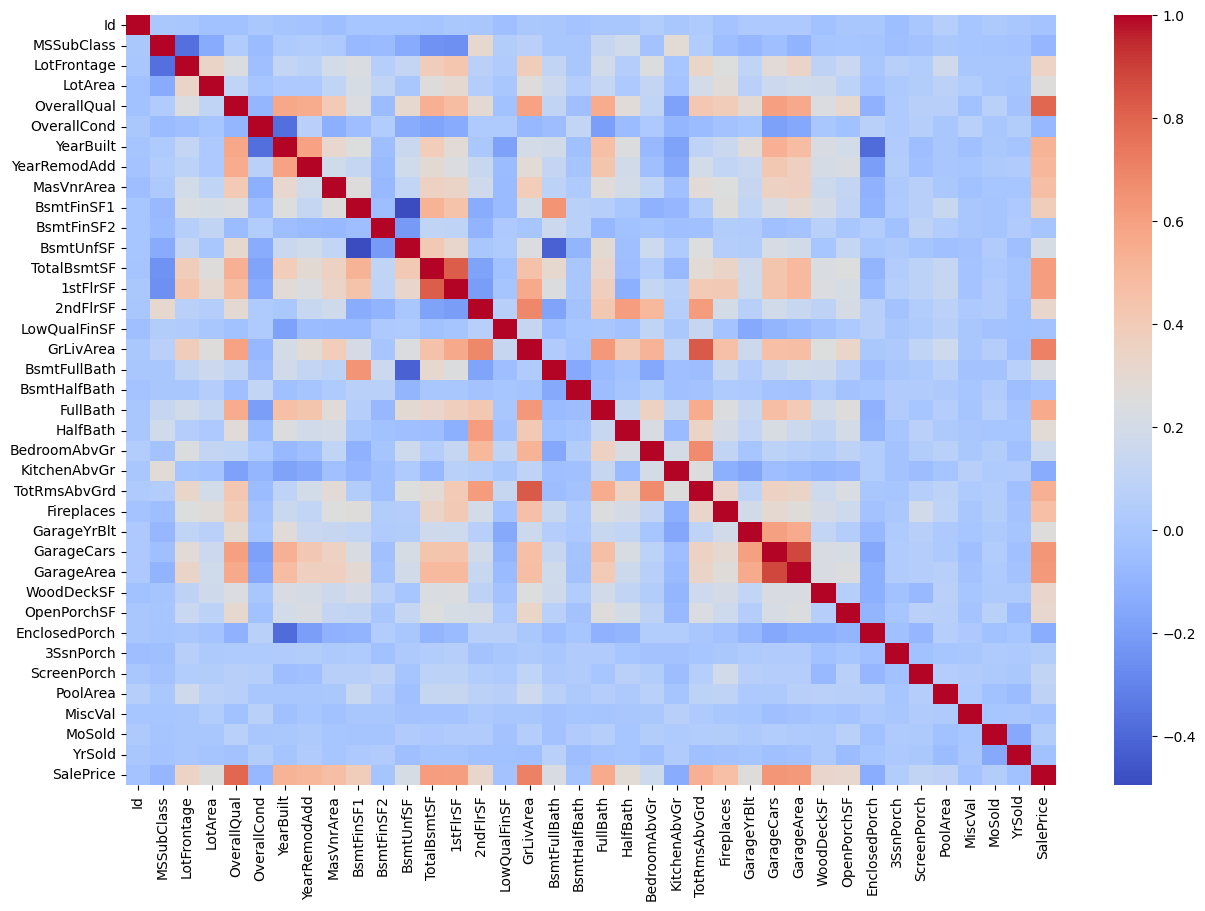

In [ ]:
# Correlation heatmap
corr = df.corr(
    numeric_only=True
)

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

In [ ]:
# Features Most Correlated with Price
corr["SalePrice"].sort_values(
    ascending=False
)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


# **Observation:**

The correlation analysis shows that some features have a strong positive relationship with house prices (SalePrice). The most influential variables are OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), TotalBsmtSF (0.61), and 1stFlrSF (0.61).

Features such as FullBath, TotRmsAbvGrd, YearBuilt, and YearRemodAdd also exhibit moderate positive correlations with the target variable. On the other hand, variables like KitchenAbvGr, EnclosedPorch, and MSSubClass show weak or negative correlations with SalePrice.

The heatmap indicates that several features are moderately correlated with one another, but no severe multicollinearity is immediately evident. Based on these results, the highly correlated features will be selected for model training and house price prediction.

# **10. Data Preprocessing**

In [ ]:
# Identify Numerical and Categorical Features

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

cat_cols = df.select_dtypes(include=["object"]).columns

In [ ]:
# Separate Features and Target Variable
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

In [ ]:
# view numerical features
print("Numerical features:")
print(*num_cols, sep="\n")

Numerical features:
Id
MSSubClass
LotFrontage
LotArea
OverallQual
OverallCond
YearBuilt
YearRemodAdd
MasVnrArea
BsmtFinSF1
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
TotRmsAbvGrd
Fireplaces
GarageYrBlt
GarageCars
GarageArea
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
MiscVal
MoSold
YrSold
SalePrice


In [ ]:
# view categorical features
print("Categorical features:")
print(*cat_cols, sep="\n")

Categorical features:
MSZoning
Street
Alley
LotShape
LandContour
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
PoolQC
Fence
MiscFeature
SaleType
SaleCondition


In [ ]:
# Apply One-Hot Encoding to Categorical Features

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# **Observation**

During preprocessing, the dataset was divided into predictor variables (X) and the target variable (SalePrice). The numerical and categorical features were identified based on their data types. One-hot encoding was applied to categorical variables to convert them into numerical format suitable for machine-learning models.

# **11. Train-Test Split (80/20 split)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **12. Model Building**

In [ ]:
# Build the pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [ ]:
# Train the Model
model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'Ex..., 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
X_train.shape
X_test.shape

(292, 79)

# **13. Prediction**

In [ ]:
y_pred = model.predict(
    X_test
)

# **14. Model Evaluation**

In [ ]:
# Mean Squared Error
mse = mean_squared_error(
    y_test,
    y_pred
)

In [ ]:
# Root Mean Squared Error
rmse = np.sqrt(mse)

In [ ]:
# R² Score
r2 = r2_score(
    y_test,
    y_pred
)

In [ ]:
# Display Results
print("MSE:", mse)

print("RMSE:", rmse)

print("R²:", r2)

MSE: 952794590.5233762
RMSE: 30867.37096876532
R²: 0.875781737987805


##Observation:

The Linear Regression model achieved an R² score of 0.876, indicating that approximately 87.6% of the variation in house prices can be explained by the selected features. The model recorded an MSE of 952,794,590.52 and an RMSE of 30,867.37, showing that the predictions are reasonably close to the actual house prices.

Overall, the model demonstrates strong predictive performance and is capable of estimating house prices with a high level of accuracy. However, the remaining unexplained variance suggests that additional features or more advanced models could further improve performance.

# **15. Model Visualization**

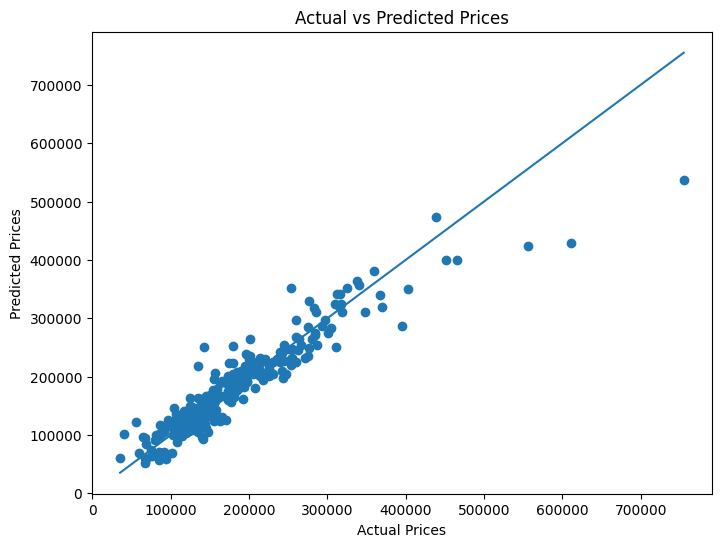

In [ ]:
#Actual vs Predicted Prices
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

##Observation:

The scatter plot shows a strong relationship between the actual and predicted house prices. Most points lie close to the diagonal line, indicating that the Linear Regression model performs well in predicting house prices. However, some points deviate from the line, especially for houses with very high prices, suggesting slight prediction errors for extreme values.

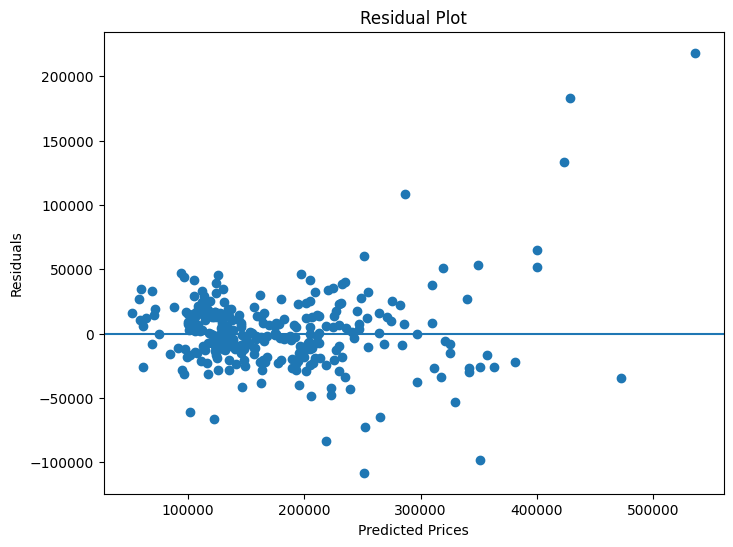

In [ ]:
# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(y=0)

plt.xlabel("Predicted Prices")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

##Observation:

The residuals are distributed around zero, indicating that the model captures the overall trend in the data. However, the spread of residuals increases for higher predicted prices, suggesting that the model performs slightly less accurately for expensive houses.

# **16. Coefficient Analysis**

In [ ]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

# Create a DataFrame for feature coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort coefficients
coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

# Display top coefficients
coef_df.head(10)

,Feature,Coefficient
40,cat__Neighborhood_NoRidge,44173.042054
47,cat__Neighborhood_StoneBr,43266.153691
221,cat__PoolQC_Ex,27790.191668
41,cat__Neighborhood_NridgHt,26159.500989
115,cat__Exterior2nd_ImStucc,25191.755084
96,cat__Exterior1st_BrkFace,20916.691760
142,cat__BsmtQual_Ex,20335.859313
92,cat__RoofMatl_WdShngl,19588.404330
183,cat__KitchenQual_Ex,19308.503919
14,cat__LandContour_HLS,19153.754942


<Figure size 1000x800 with 0 Axes>

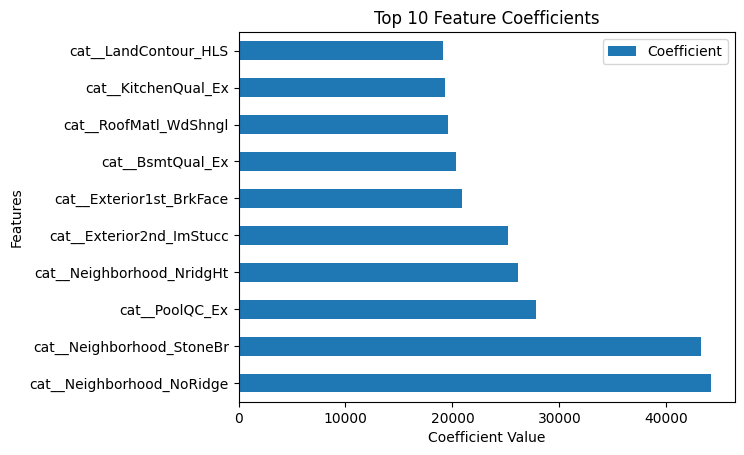

In [ ]:
#coefficient importance plot
plt.figure(figsize=(10, 8))

coef_df.head(10).plot(
    x='Feature',
    y='Coefficient',
    kind='barh'
)

plt.title("Top 10 Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.show()

# Observation:

The coefficient analysis reveals that several neighborhood-related features have the strongest positive influence on house prices. In particular, houses located in neighborhoods such as NoRidge and StoneBr have the highest positive coefficients, indicating that properties in these areas tend to have significantly higher selling prices.

Additionally, features such as excellent pool quality (PoolQC_Ex), excellent basement quality (BsmtQual_Ex), excellent kitchen quality (KitchenQual_Ex), and premium exterior materials such as brick facades (Exterior1st_BrkFace) contribute positively to house prices. The positive coefficient associated with LandContour_HLS also suggests that houses situated on elevated land are generally more expensive.

Overall, the coefficient analysis demonstrates that location, construction quality, and premium amenities are among the most important factors influencing house prices in the Ames Housing dataset. Features with larger positive coefficients have a greater impact on increasing the predicted sale price.

# **17. Ridge Regression**

In [ ]:
# Train the Ridge model
# Create a pipeline for Ridge Regression, including the preprocessor
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

# Train the model
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [ ]:
# make predictions
ridge_pred = ridge_model.predict(X_test)

In [ ]:
# Evaluate the model
ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R² Score:", ridge_r2)

Ridge MSE: 1180415704.4370315
Ridge RMSE: 34357.17835383214
Ridge R² Score: 0.8461061925461557


In [ ]:
# comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'RMSE': [30867.37, 34357.18],
    'R² Score': [0.876, 0.846]
})

comparison

,Model,RMSE,R² Score
0,Linear Regression,30867.37,0.876
1,Ridge Regression,34357.18,0.846


##Observation:

Ridge Regression was implemented as a regularized version of Linear Regression to reduce overfitting and improve model generalization. The performance of both models was compared using RMSE and the R² score.

The Linear Regression model achieved an RMSE of 30,867.37 and an R² score of 0.876, while the Ridge Regression model recorded an RMSE of 34,357.18 and an R² score of 0.846.

Based on these results, Linear Regression outperformed Ridge Regression, as it produced a lower prediction error and explained a larger proportion of the variance in house prices. Therefore, Linear Regression was selected as the better-performing model for this dataset.

# **18. Conclusion**

This project aimed to develop a machine learning model capable of predicting house prices using the Ames Housing dataset. The dataset was explored and analyzed to identify the factors that influence property prices. Data cleaning techniques were applied to handle missing values and prepare the dataset for analysis. In addition, categorical variables were encoded, and the data was preprocessed to ensure compatibility with machine learning algorithms.

Exploratory Data Analysis (EDA) and correlation analysis revealed that several factors, including neighborhood, house quality, basement quality, kitchen quality, exterior materials, and land contour, have a significant impact on house prices. The coefficient analysis further confirmed that location and premium housing features are among the strongest determinants of property value.

A Linear Regression model was trained and evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). The model achieved an RMSE of 30,867.37 and an R² score of 0.876, indicating that approximately 87.6% of the variation in house prices can be explained by the selected features.

As a bonus, a Ridge Regression model was also implemented and compared with the Linear Regression model. Ridge Regression achieved an RMSE of 34,357.18 and an R² score of 0.846. Although Ridge Regression helps reduce overfitting through regularization, the Linear Regression model demonstrated superior predictive performance on this dataset.

Overall, the results show that Linear Regression is an effective approach for house price prediction in the Ames Housing dataset. Future improvements could involve experimenting with more advanced algorithms, feature engineering, and hyperparameter tuning to further enhance model performance.